In [1]:
import pandas as pd
import numpy as np

In [3]:
import matplotlib.pyplot as plt

import seaborn as sns

In [4]:
df=pd.read_csv('../data/featured_data/gurgaon_properties_cleaned_v2.csv')

In [5]:
df.shape

(3803, 23)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3803 entries, 0 to 3802
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_type        3803 non-null   object 
 1   society              3802 non-null   object 
 2   sector               3803 non-null   object 
 3   price                3785 non-null   float64
 4   price_per_sqft       3785 non-null   float64
 5   area                 3785 non-null   float64
 6   areaWithType         3803 non-null   object 
 7   bedRoom              3803 non-null   int64  
 8   bathroom             3803 non-null   int64  
 9   balcony              3803 non-null   object 
 10  floorNum             3784 non-null   float64
 11  facing               2698 non-null   object 
 12  agePossession        3803 non-null   object 
 13  super_built_up_area  1915 non-null   float64
 14  built_up_area        1733 non-null   float64
 15  carpet_area          1944 non-null   f

In [7]:
df.duplicated().sum()

np.int64(126)

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.shape

(3677, 23)

In [112]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flats,rof ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64412 (5984.07 sq.m.),3,2,1,...,NaN,NaN,64412.000000,0,0,0,0,0,1,51
1,flats,breez global hill view,sohna road,0.35,6315.0,554.0,Carpet area: 554.16 (51.48 sq.m.),2,2,2,...,NaN,NaN,554.125572,0,0,0,0,0,1,53
2,flats,tulip violet,sector 69,1.65,8872.0,1860.0,Built Up area: 1578 (146.6 sq.m.),3,3,2,...,NaN,1578.0,NaN,0,0,0,0,0,0,69
3,house,suncity township,sector 54,25.00,31111.0,8036.0,Plot area 1000(836.13 sq.m.),4,4,3+,...,NaN,1000.0,NaN,0,0,0,0,0,1,0
4,flats,shree vardhman victoria,sector 70,1.75,8974.0,1950.0,Built Up area: 1950 (181.16 sq.m.),3,5,0,...,NaN,1950.0,NaN,0,0,0,0,0,1,47


### univariate analysis

<Axes: xlabel='property_type'>

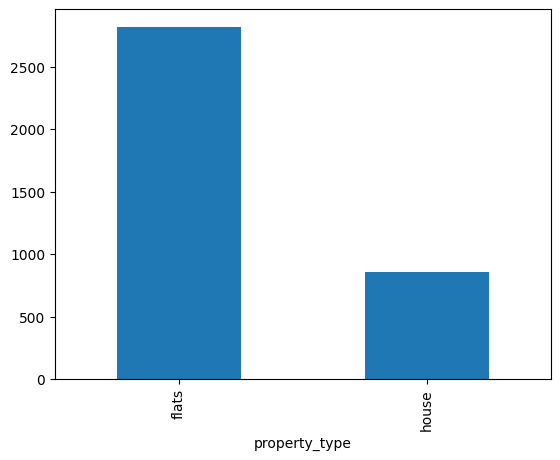

In [10]:
#property_type
df['property_type'].value_counts().plot(kind='bar')

 observation
- flats are in majority(more than 75 percent) and houses are less than 25 percent
- no missing values

In [11]:
#society
df['society'].value_counts() #high cardinality, 676 categories

society
independent                                          486
tulip violet                                          75
ss the leaf                                           73
dlf new town heights                                  42
shapoorji pallonji joyville gurugram                  42
                                                    ... 
city heights                                           1
satya the legend                                       1
arjun marg/ sector- 26 phase- 1/ golf course road      1
shyam apartment                                        1
emaar mgf palm terraces                                1
Name: count, Length: 676, dtype: int64

In [12]:
df[df['society']!='independent']['society'].value_counts(normalize=True).cumsum().head(75)
#means 50 percent of the flats comes form first 75 categories of society column

society
tulip violet                            0.023511
ss the leaf                             0.046395
dlf new town heights                    0.059561
shapoorji pallonji joyville gurugram    0.072727
signature global park                   0.083699
                                          ...   
puri emerald bay                        0.490282
umang monsoon breeze                    0.494357
indiabulls enigma                       0.498433
unitech uniworld resorts                0.502194
mvn athens                              0.505956
Name: proportion, Length: 75, dtype: float64

In [13]:
df['society'].isnull().sum()

np.int64(1)

In [14]:
df[df['society'].isnull()]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2301,flats,NaN,sector 78,0.6,3692.0,1625.0,Built Up area: 1625 (150.97 sq.m.),2,2,0,...,NaN,1625.0,NaN,0,0,0,0,0,1,0


In [15]:
society_counts = df['society'].value_counts()

# Frequency distribution for societies
frequency_bins = {
    "Very High (>100)": (society_counts > 100).sum(),
    "High (50-100)": ((society_counts >= 50) & (society_counts <= 100)).sum(),
    "Average (10-49)": ((society_counts >= 10) & (society_counts < 50)).sum(),
    "Low (2-9)": ((society_counts > 1) & (society_counts < 10)).sum(),
    "Very Low (1)": (society_counts == 1).sum()
}
frequency_bins

{'Very High (>100)': np.int64(1),
 'High (50-100)': np.int64(2),
 'Average (10-49)': np.int64(92),
 'Low (2-9)': np.int64(273),
 'Very Low (1)': np.int64(308)}

<Axes: xlabel='society'>

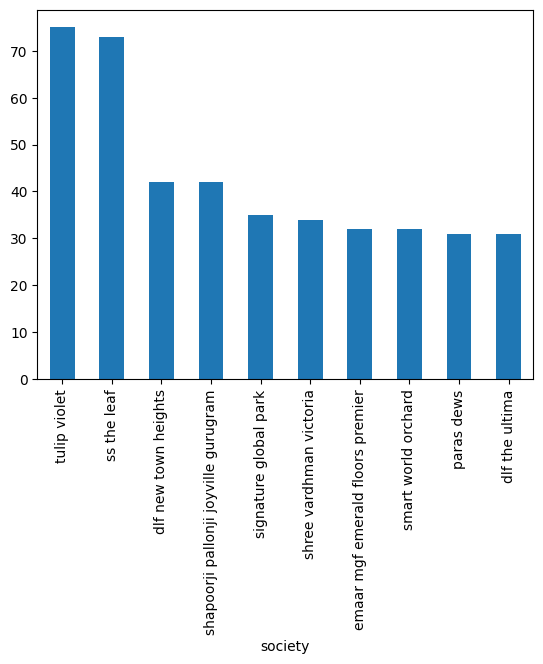

In [16]:
df[df['society'] != 'independent']['society'].value_counts().head(10).plot(kind='bar')

observations
- 13% properties are independent houses
- 675 societies
- the top 75 societies have 50 percent of the properties and the rest 50 pervcent of the properties come under the remaining 600 societies
  - very high(>100): only 1 society has more than 100 listings
  - high (50-100): 2 societies have between 50 to 100 lisitngs.
  - average(10-49): 92 societies fall in this range with 10 to 49 listings each
  - low(2-9): 273 socities have between 2 to 9 listings
  - very low(1): a significant number, 308 societies only have 1 listing
- 1 missing value

In [17]:
#sector
df['sector'].value_counts()#high cardinality column

sector
sohna road    154
sector 85     108
sector 102    107
sector 92     100
sector 69      93
             ... 
sector 17b      3
sector 88b      3
sector 27       3
sector 17a      3
sector 37       1
Name: count, Length: 115, dtype: int64

<Axes: xlabel='sector'>

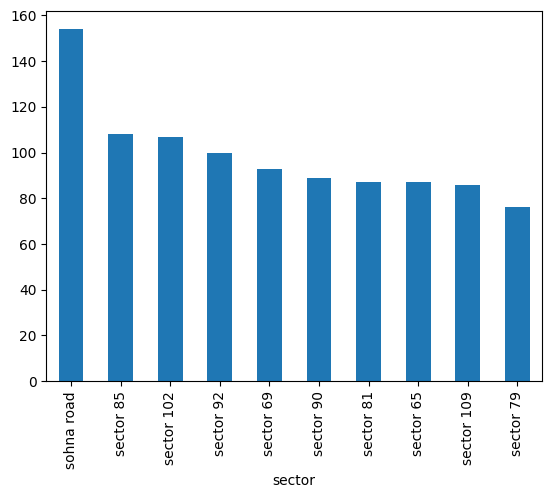

In [18]:
df['sector'].value_counts().head(10).plot(kind='bar')

In [19]:
# Frequency distribution for sectors
sector_counts = df['sector'].value_counts()

sector_frequency_bins = {
    "Very High (>100)": (sector_counts > 100).sum(),
    "High (50-100)": ((sector_counts >= 50) & (sector_counts <= 100)).sum(),
    "Average (10-49)": ((sector_counts >= 10) & (sector_counts < 50)).sum(),
    "Low (2-9)": ((sector_counts > 1) & (sector_counts < 10)).sum(),
    "Very Low (1)": (sector_counts == 1).sum()
}

sector_frequency_bins

{'Very High (>100)': np.int64(3),
 'High (50-100)': np.int64(25),
 'Average (10-49)': np.int64(63),
 'Low (2-9)': np.int64(23),
 'Very Low (1)': np.int64(1)}

observations:
- there are total of 115 unique sectors
- freq distribution of sectors:
  - very high(>100):3 sectrors have more than 100 listings
  - high(50-100): 25 sectors have between 50 to 100 listings
  - average(10-49): 63 sectors fall in the range of 10-49 listings each
  - low(2-9): 23 sectors have between 2-9 listings each
  - very low(1): 1 sector have 1 listing 

In [20]:
#price(important col, since this is going to be our output column)
df['price'].isnull().sum()

np.int64(17)

In [21]:
df['price'].info()

<class 'pandas.core.series.Series'>
Index: 3677 entries, 0 to 3801
Series name: price
Non-Null Count  Dtype  
--------------  -----  
3660 non-null   float64
dtypes: float64(1)
memory usage: 57.5 KB


In [22]:
df['price'].describe()

count    3660.000000
mean        2.533664
std         2.980623
min         0.070000
25%         0.950000
50%         1.520000
75%         2.750000
max        31.500000
Name: price, dtype: float64

<Axes: xlabel='price', ylabel='Count'>

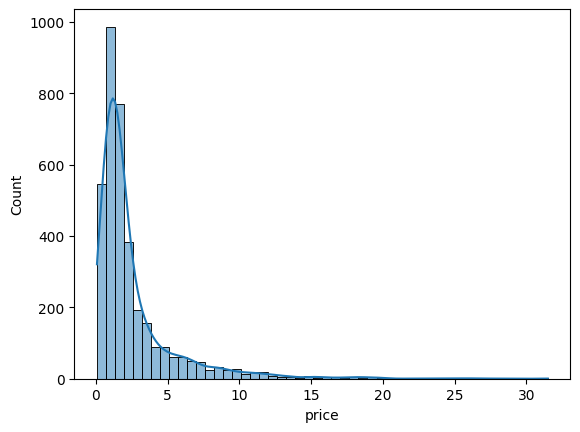

In [23]:
sns.histplot(df['price'],kde=True,bins=50)

<Axes: xlabel='price'>

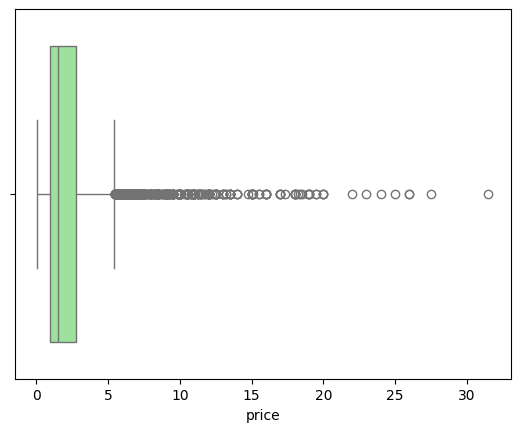

In [24]:
sns.boxplot(x=df['price'],color='lightgreen')

- descriptive statistics
  - Count: There are 3,660 non-missing price entries.
  - Mean Price: The average price is approximately 2.53 crores.
  - Median Price: The median (or 50th percentile) price is 1.52 crores.
  - Standard Deviation: The prices have a standard deviation of 2.98,
  indicating variability in the prices.
  - Range: Prices range from a minimum of 0.07 crores to a maximum of 31.5 crores.
  - IQR: The interquartile range (difference between 75th and 25th percentile) is from 0.95 crores to 2.75 crores.

- visualizations:
  - Distribution: The histogram indicates that most properties are priced in the lower range (below 5 crores), with a few properties going beyond 10 crores.
  - Box Plot: The box plot showcases the spread of the data and potential outliers. Properties priced above approximately 10 crores might be considered outliers as they lie beyond the upper whisker of the box plot

-missing values: there are 17 missing values in the price column

In [25]:
# Skewness and Kurtosis
skewness = df['price'].skew()
kurtosis = df['price'].kurt() #kurtosis tells how heavy the tail is, indicating the weight of the outliers

print(skewness,kurtosis)

3.2791704733134623 14.933372629214258



Skewness: The price distribution has a skewness of approximately 3.28, indicating a positive skew. This means that the distribution tail is skewed to the right, which aligns with our observation from the histogram where most properties have prices on the lower end with a few high-priced properties.

Kurtosis: The kurtosis value is approximately 14.93. A kurtosis value greater than 3 indicates a distribution with heavier tails and more outliers compared to a normal distribution.

In [26]:
# Quantile Analysis
quantiles = df['price'].quantile([0.01, 0.05, 0.95, 0.99])

quantiles

0.01     0.250
0.05     0.370
0.95     8.500
0.99    15.264
Name: price, dtype: float64


Quantile Analysis:

  - 1% Quantile: Only 1% of properties are priced below 0.25 crores.
  - 5% Quantile: 5% of properties are priced below 0.37 crores.
  - 95% Quantile: 95% of properties are priced below 8.5 crores.
  - 99% Quantile: 99% of properties are priced below 15.26 crores, indicating that very few properties are priced above this value.

In [27]:
#identify potential putliers using IQR method
Q1= df['price'].describe()['25%']
Q3=df['price'].describe()['75%']
IQR=Q3-Q1

In [28]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound, upper_bound)

-1.7500000000000002 5.45


In [29]:
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
outliers.shape

(425, 23)

In [30]:
outliers['price'].describe()

count    425.000000
mean       9.235624
std        4.065259
min        5.460000
25%        6.460000
50%        8.000000
75%       10.750000
max       31.500000
Name: price, dtype: float64

Outliers Analysis (using IQR method):

-  Based on the IQR method, there are 425 properties considered as outliers.
- These outliers have an average price of approximately 9.24 crores.
-  The range for these outliers is from 5.46 crores to 31.5 crores.

<Axes: xlabel='price'>

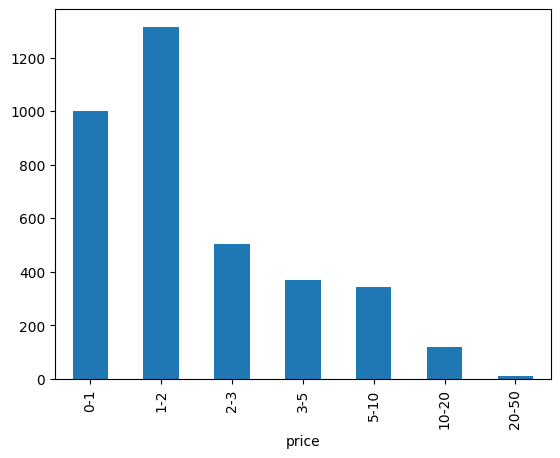

In [31]:
# price binning
bins = [0, 1, 2, 3, 5, 10, 20, 50]
bin_labels = ["0-1", "1-2", "2-3", "3-5", "5-10", "10-20", "20-50"]
pd.cut(df['price'], bins=bins, labels=bin_labels, right=False).value_counts().sort_index().plot(kind='bar')

- majority of the properties are priced in 1,2 and 2-3 crores range
- there is significant drop in the no.of properties above 5 crores

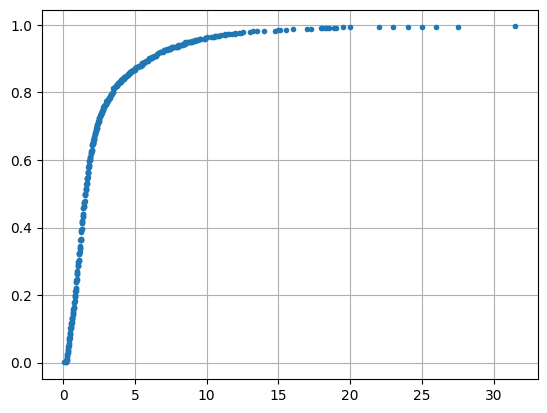

In [32]:
ecdf=df['price'].value_counts().sort_index().cumsum()/ len(df['price'])
plt.plot(ecdf.index, ecdf, marker= '.', linestyle='none')
plt.grid()

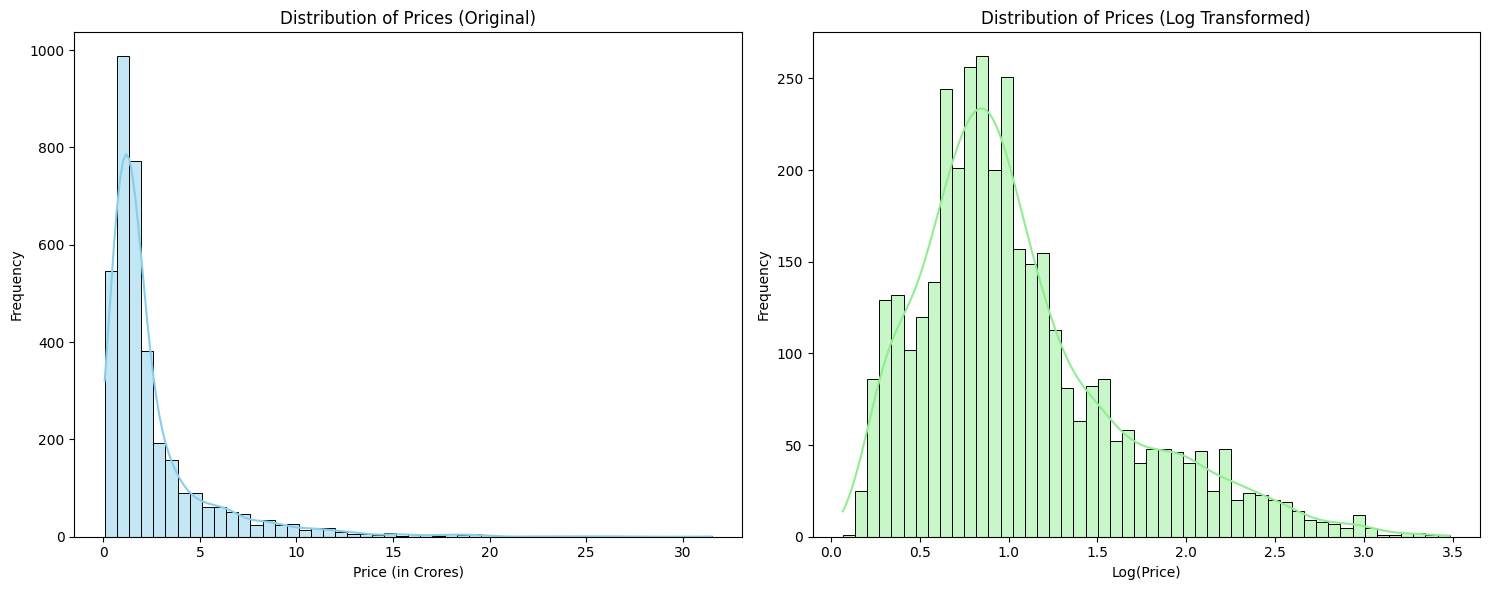

In [33]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.histplot(df['price'], kde=True, bins=50, color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['price']), kde=True, bins=50, color='lightgreen')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

np.log1p(x): This function computes the natural logarithm of 1+x. It's designed to provide more accurate results for values of x that are very close to zero.

Using np.log1p helps in transforming the price column while ensuring that any value (including zero, if present) is handled appropriately. When we need to reverse the transformation, we can use np.expm1 which computes e^x-1

In [34]:
skewness = np.log1p(df['price']).skew()
kurtosis = np.log1p(df['price']).kurt()

print(skewness,kurtosis)

1.0740709565255315 0.9646692415449296


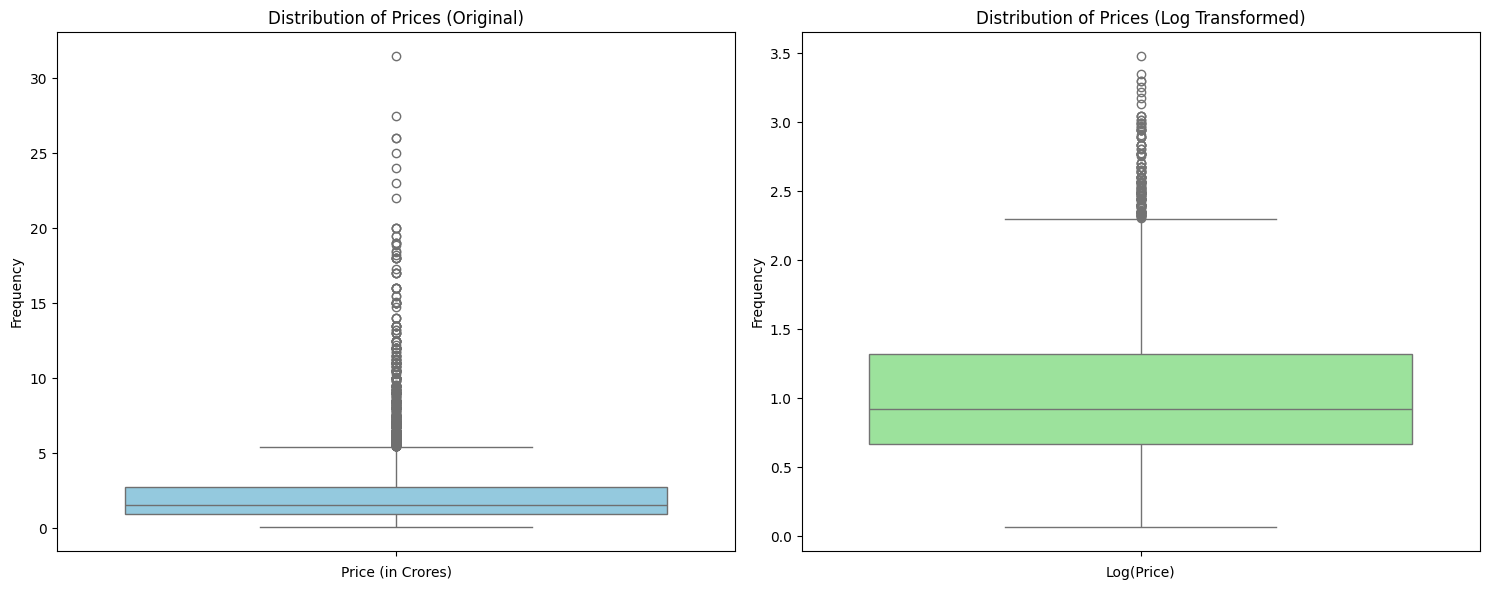

In [35]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.boxplot(df['price'], color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.boxplot(np.log1p(df['price']), color='lightgreen')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [36]:
#price_per_sqft
df['price_per_sqft'].isnull().sum()

np.int64(17)

In [37]:
df['price_per_sqft'].describe()

count      3660.000000
mean      13892.668306
std       23210.067190
min           4.000000
25%        6817.250000
50%        9020.000000
75%       13880.500000
max      600000.000000
Name: price_per_sqft, dtype: float64

<Axes: xlabel='price_per_sqft', ylabel='Count'>

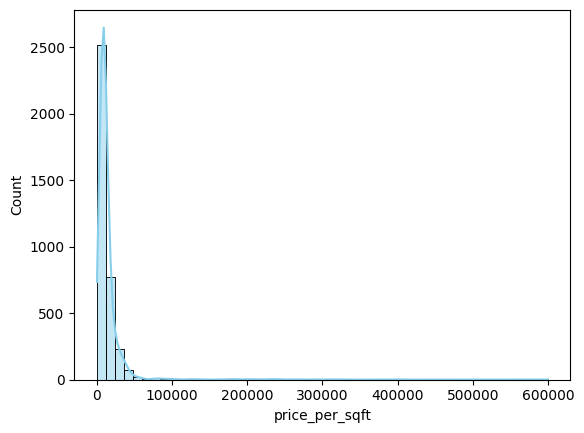

In [38]:
sns.histplot(df['price_per_sqft'],bins=50,color='skyblue',kde=True)

Most properties have a price_per_sqft ranging between approximately ₹0 and ₹40,000. There is a significant concentration in the lower range, with a few properties having exceptionally high price_per_sqft.

<Axes: ylabel='price_per_sqft'>

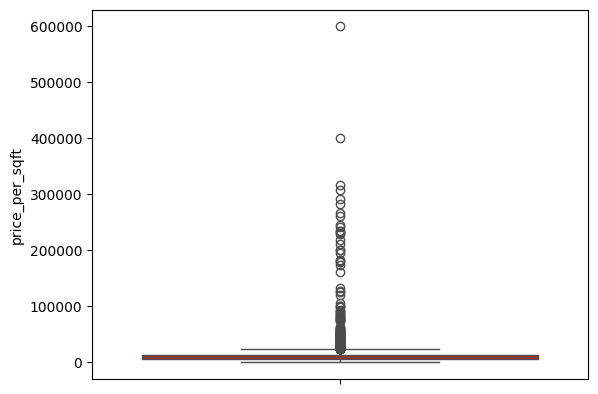

In [39]:
sns.boxplot(df['price_per_sqft'],color='red')

The box plot clearly shows several outliers, especially on the higher side. The interquartile range (IQR) is relatively compact, but there are many data points beyond the "whiskers" of the box plot, indicating potential outliers

* Observations
   - Potential Outliers
   - Right Skewed
   - 17 missing values

In [40]:
#bedRoom
df['bedRoom'].isnull().sum()

np.int64(0)

<Axes: xlabel='bedRoom'>

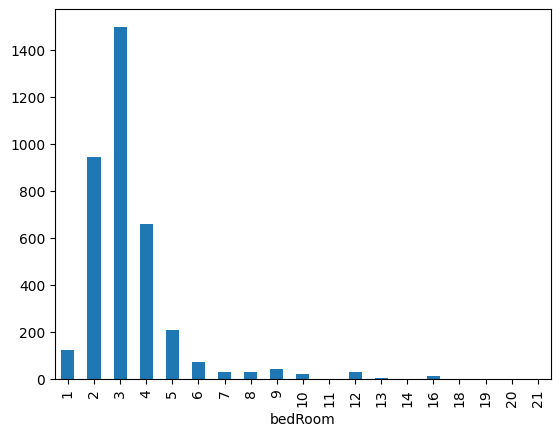

In [41]:
df['bedRoom'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='proportion'>

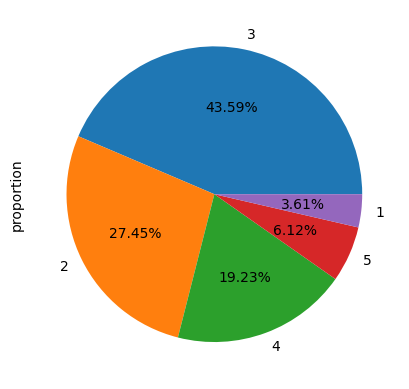

In [42]:
df['bedRoom'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

In [43]:
#bathroom
df['bathroom'].isnull().sum()

np.int64(0)

<Axes: xlabel='bathroom'>

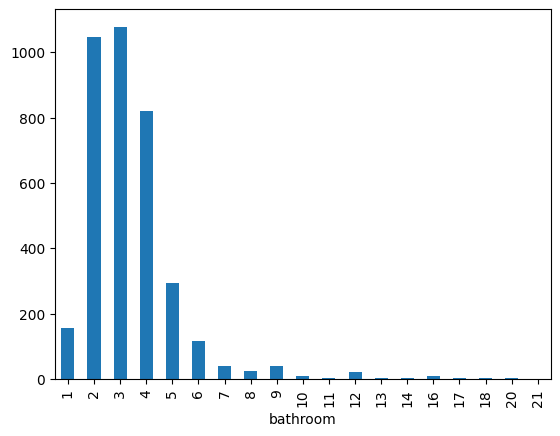

In [44]:
df['bathroom'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='proportion'>

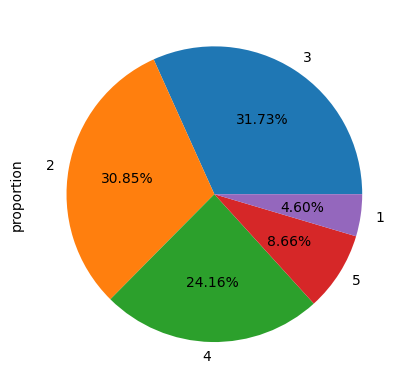

In [45]:
df['bathroom'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

In [46]:
#balcony
df['balcony'].isnull().sum()

np.int64(0)

<Axes: xlabel='balcony'>

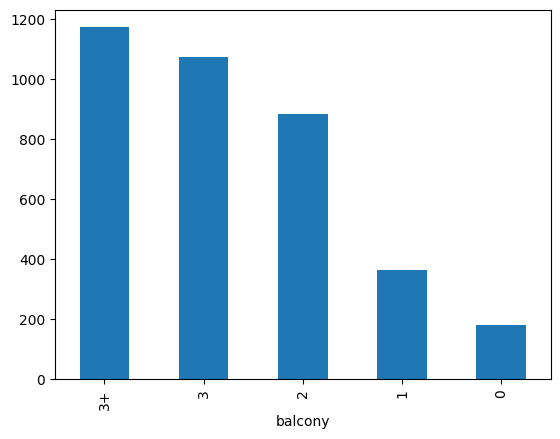

In [47]:
df['balcony'].value_counts().plot(kind='bar')

<Axes: ylabel='proportion'>

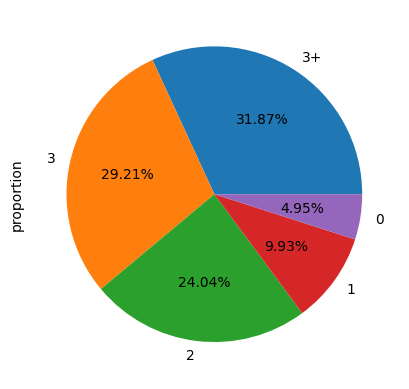

In [48]:
df['balcony'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

In [49]:
##floorNum
df['floorNum'].isnull().sum()

np.int64(19)

In [50]:
df['floorNum'].describe()

count    3658.000000
mean        6.798250
std         6.012454
min         0.000000
25%         2.000000
50%         5.000000
75%        10.000000
max        51.000000
Name: floorNum, dtype: float64

<Axes: xlabel='floorNum'>

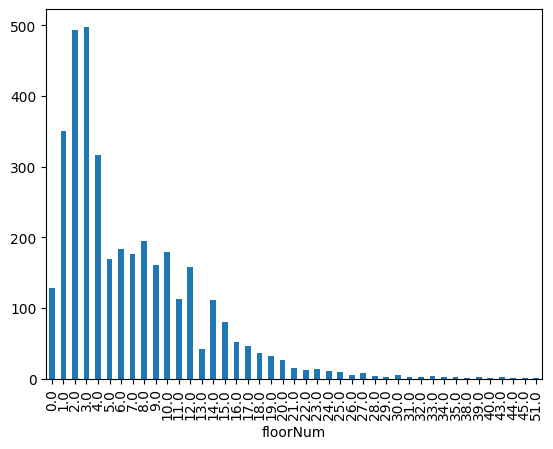

In [51]:
df['floorNum'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='floorNum'>

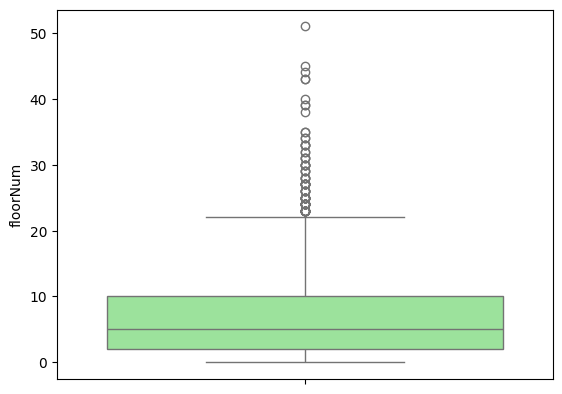

In [52]:
sns.boxplot(df['floorNum'], color='lightgreen')

-  The majority of the properties lie between the ground floor (0) and the 25th floor.
-  Floors 1 to 4 are particularly common, with the 3rd floor being the most frequent.
-  There are a few properties located at higher floors, but their frequency is much lower.
-  The box plot reveals that the majority of the properties are concentrated around the lower floors. The interquartile range (IQR) lies between approximately the 2nd and 10th floors.
-  Data points beyond the "whiskers" of the box plot, especially on the higher side, indicate potential outliers.

In [53]:
#facing
df['facing'].isnull().sum()

np.int64(1045)

In [54]:
df['facing']=df['facing'].fillna('NA')

In [55]:
df['facing'].value_counts()

facing
NA            1045
East           623
North-East     623
North          387
West           249
South          231
North-West     193
South-East     173
South-West     153
Name: count, dtype: int64

In [56]:
#agepossesion
df['agePossession'].isnull().sum()

np.int64(0)

In [57]:
df['agePossession'].value_counts()

agePossession
Relatively New        1646
New Property           593
Moderately Old         563
Undefined              438
Old Property           303
Under Construction     134
Name: count, dtype: int64

In [58]:
#areas
#builtt up area- whole area of your house including balcony
#carpet area: built up area - balcony -thickness of walls
#super built up area: built up area+ common area(staircase area, lift)
#30% difference between super built up and carpet area

In [59]:
#super built up area 
df['super_built_up_area'].isnull().sum()

np.int64(1802)

In [60]:
df['super_built_up_area'].describe()

count     1875.000000
mean      1925.237627
std        764.172177
min         89.000000
25%       1479.500000
50%       1828.000000
75%       2215.000000
max      10000.000000
Name: super_built_up_area, dtype: float64

<Axes: xlabel='super_built_up_area', ylabel='Count'>

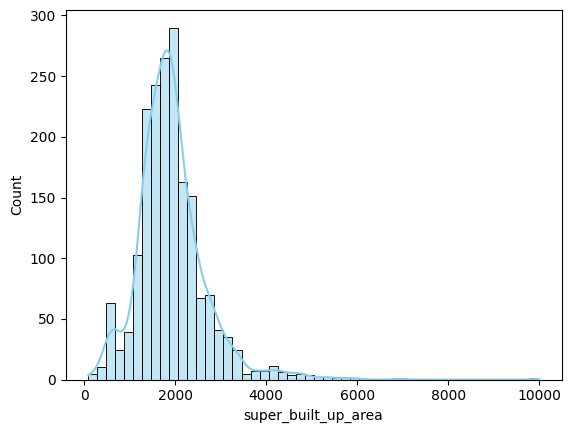

In [61]:
sns.histplot(df['super_built_up_area'].dropna(),bins=50,color='skyblue',kde=True)

<Axes: ylabel='super_built_up_area'>

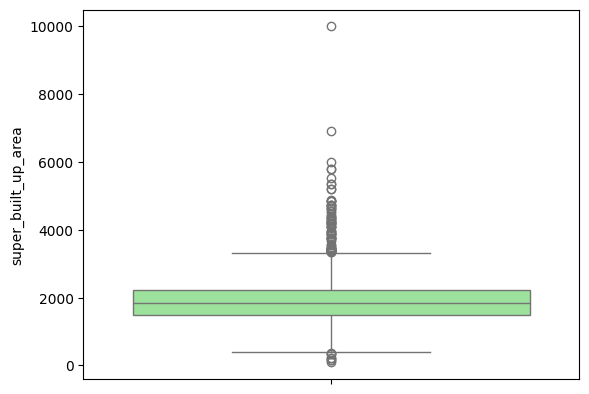

In [62]:
sns.boxplot(df['super_built_up_area'].dropna(), color='lightgreen')

- Most properties have a super built-up area ranging between approximately 1,000 sq.ft and 2,500 sq.ft.
- There are a few properties with a significantly larger area, leading to a right-skewed distribution.
- The interquartile range (IQR) lies between roughly 1,480 sq.ft and 2,215 sq.ft, indicating that the middle 50% of the properties fall within this range.
- There are several data points beyond the upper "whisker" of the box plot, indicating potential outliers. These are properties with an unusually large super built-up area.

In [63]:
#built up area
df['built_up_area'].isnull().sum()

np.int64(1987)

In [64]:
df['built_up_area'].describe()

count      1690.000000
mean       1841.931378
std       17945.374399
min           2.000000
25%         360.000000
50%        1256.500000
75%        1900.000000
max      737147.000000
Name: built_up_area, dtype: float64

<Axes: xlabel='built_up_area', ylabel='Count'>

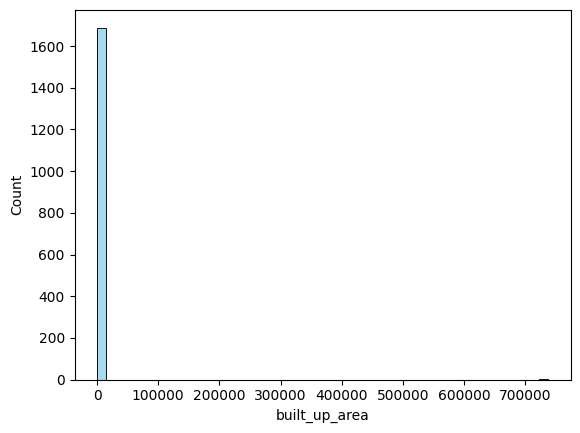

In [65]:
sns.histplot(df['built_up_area'].dropna(), bins=50, color='skyblue', kde=False)

<Axes: ylabel='built_up_area'>

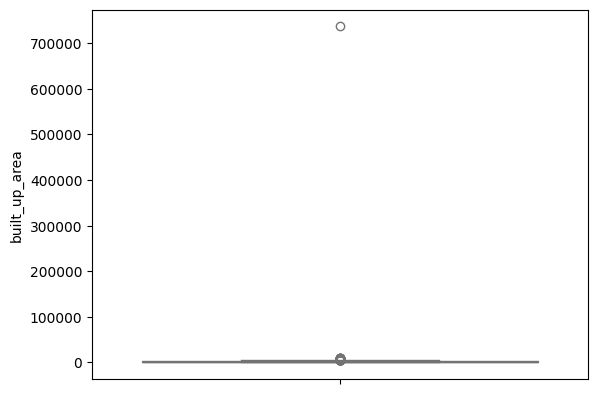

In [66]:
sns.boxplot(df['built_up_area'].dropna(), color='lightgreen')

- Most properties have a built-up area ranging roughly between 500 sq.ft and 3,500 sq.ft.
- There are very few properties with a much larger built-up area, leading to a highly right-skewed distribution.
- The box plot confirms the presence of significant outliers on the higher side. The data's interquartile range (IQR) is relatively compact, but the "whiskers" of the box plot are stretched due to the outliers.


The presence of extreme values, especially on the higher side, suggests that there may be outliers or data errors. This could also be due to some properties being exceptionally large, like a commercial complex or an entire building being listed.

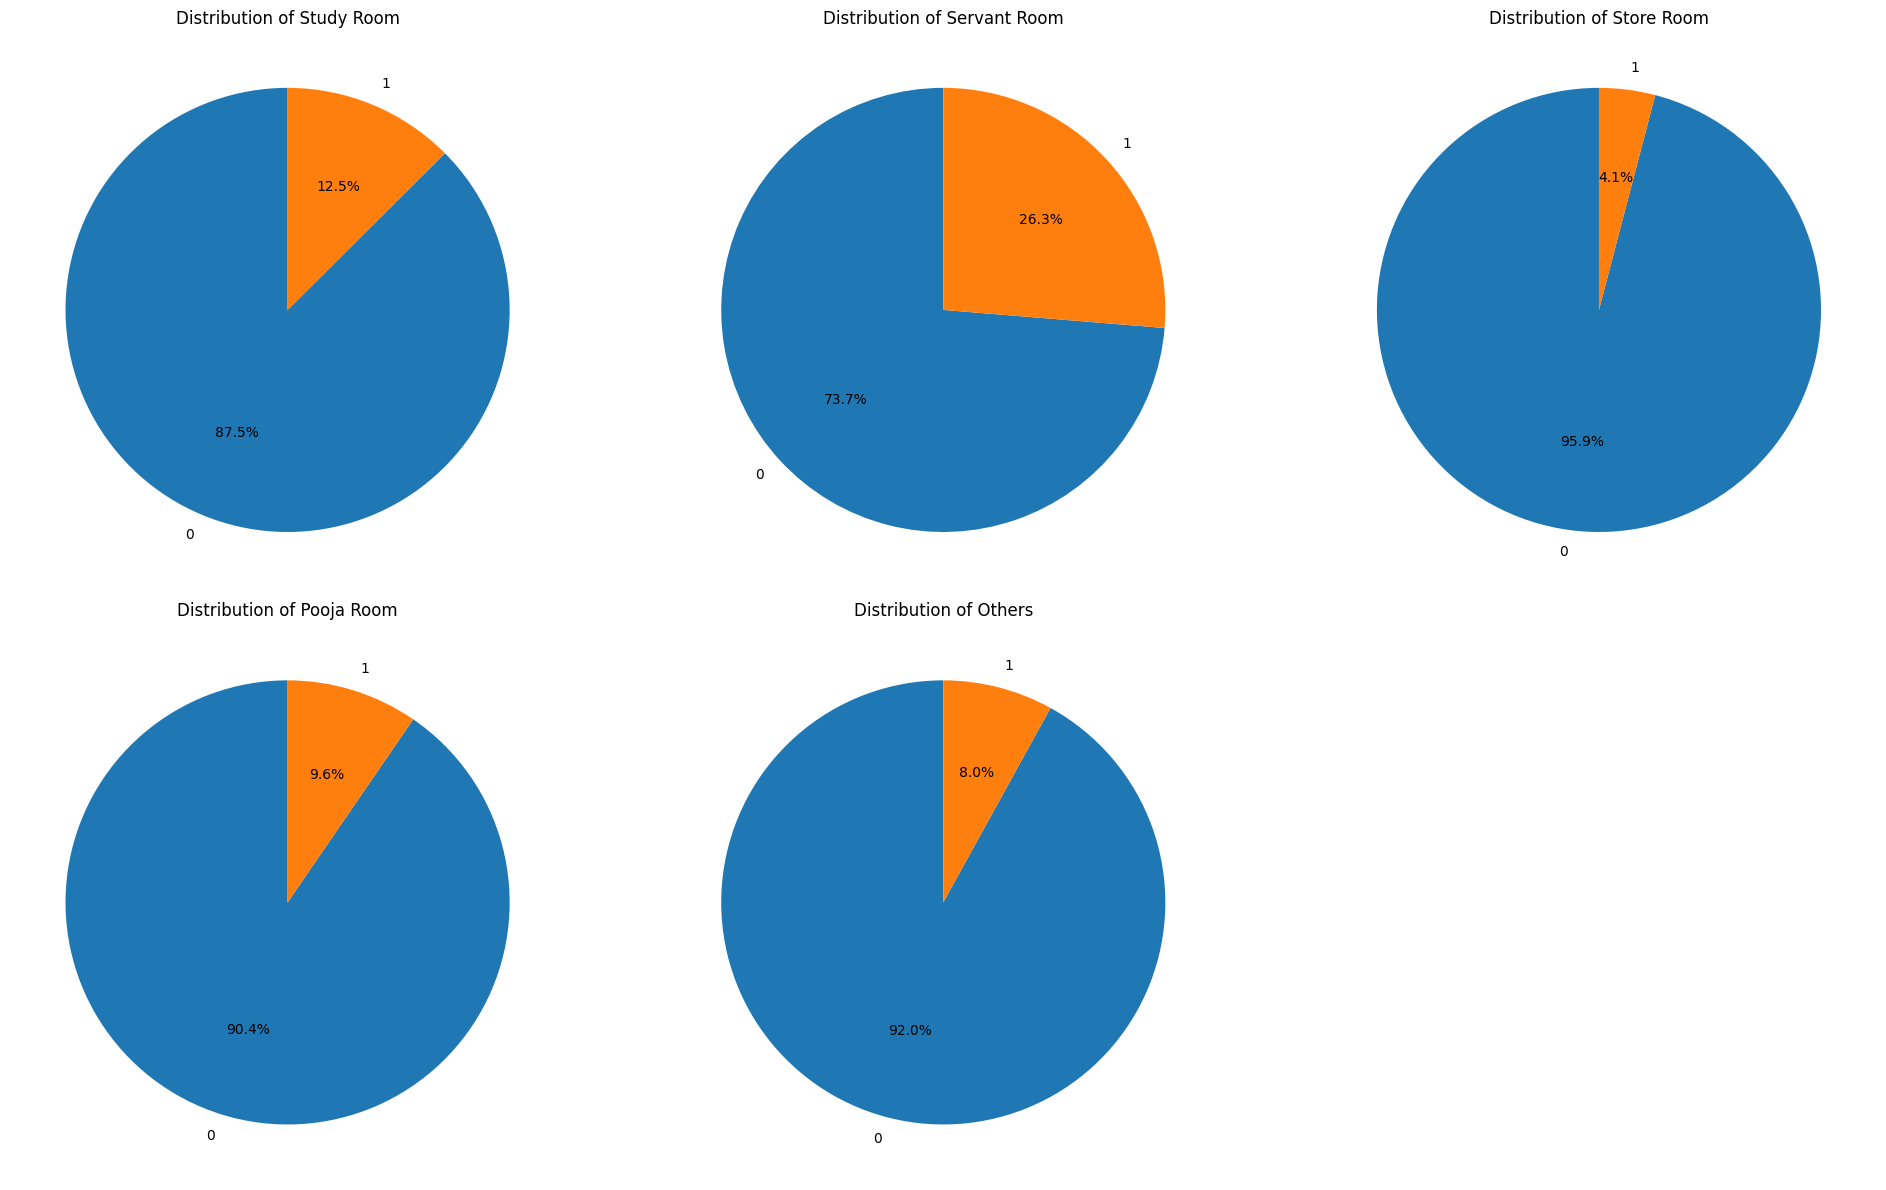

In [67]:
#additional rooms
plt.figure(figsize=(20, 12))

# Create a subplot of pie charts for each room type
for idx, room in enumerate(['study room','servant room','store room','pooja room','others'], 1):
    ax = plt.subplot(2, 3, idx)
    df[room].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, ax=ax)
    plt.title(f'Distribution of {room.title()}')
    plt.ylabel('')

plt.tight_layout()
plt.show()

In [68]:
#frunishing type
df['furnishing_type'].isnull().sum()

np.int64(0)

In [69]:
df['furnishing_type'].value_counts()
#1->unfurnished
#0->semi-furnished
#2->fully furnished

furnishing_type
1    2436
0    1038
2     203
Name: count, dtype: int64

<Axes: ylabel='count'>

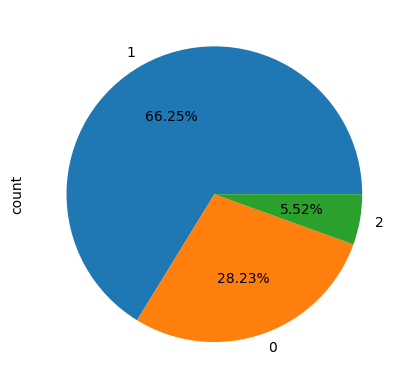

In [70]:
df['furnishing_type'].value_counts().plot(kind='pie',autopct='%0.2f%%')

In [71]:
#luxury_score
df['luxury_score'].isnull().sum()

np.int64(0)

In [72]:
df['luxury_score'].describe()

count    3677.000000
mean       71.512918
std        53.059082
min         0.000000
25%        31.000000
50%        59.000000
75%       110.000000
max       174.000000
Name: luxury_score, dtype: float64

<Axes: xlabel='luxury_score', ylabel='Count'>

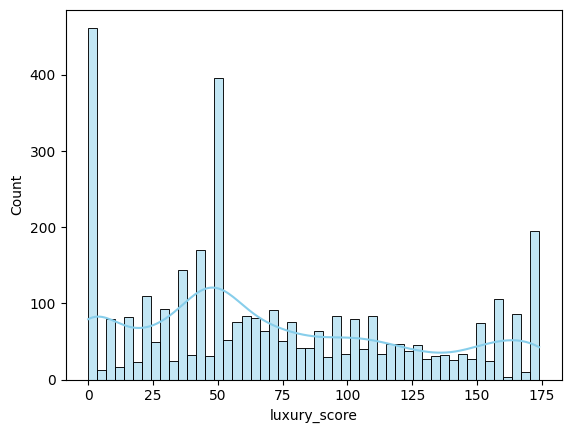

In [73]:
sns.histplot(df['luxury_score'], bins=50, color='skyblue', kde=True)

<Axes: ylabel='luxury_score'>

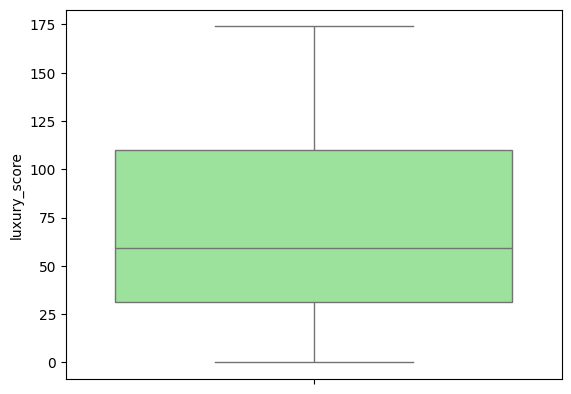

In [74]:
sns.boxplot(df['luxury_score'], color='lightgreen')

The luxury score distribution has multiple peaks, suggesting a multi-modal distribution. There's a significant number of properties with lower luxury scores (around 0-50), and another peak is observed around the 110-130 range.

The box plot reveals that the majority of the properties have luxury scores between approximately 30 and 110. The interquartile range (IQR) lies between these values.

### pandas_profiling

In [75]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Real Estate EDA Report")


c:\Users\areeb\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\areeb\AppData\Local\Temp\ipykernel_14628\2098491350.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [78]:
profile.to_file('../reports/eda_report.html')

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 34.06it/s]


### multivariate analysis

property_type vs price

<Axes: xlabel='property_type', ylabel='price'>

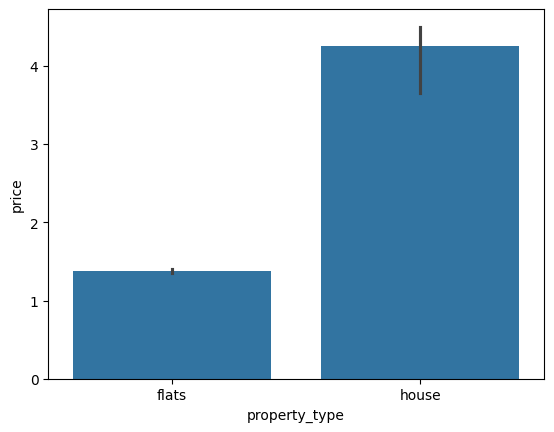

In [76]:
sns.barplot(x=df['property_type'],y=df['price'],estimator=np.median)

<Axes: xlabel='property_type', ylabel='price'>

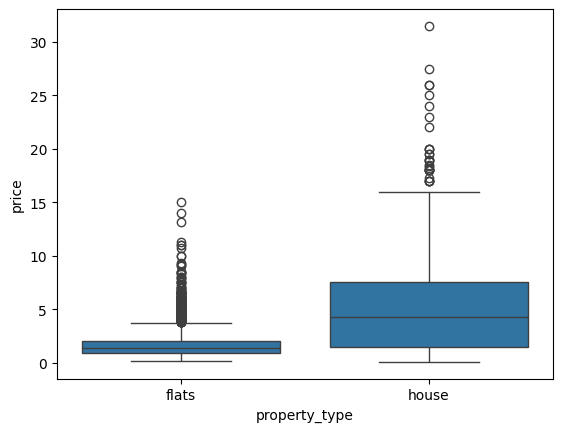

In [77]:
sns.boxplot(x=df['property_type'],y=df['price'])

property_type vs area

<Axes: xlabel='property_type', ylabel='built_up_area'>

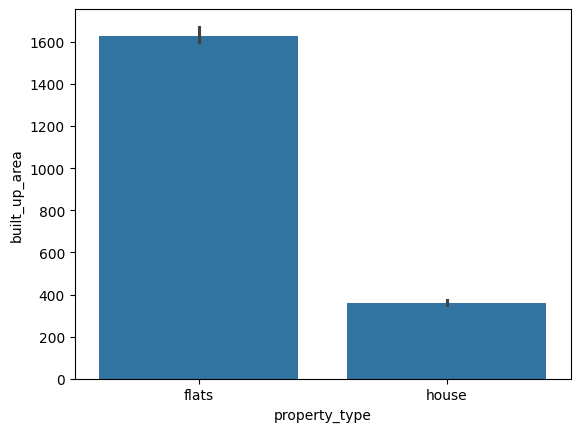

In [78]:
sns.barplot(x=df['property_type'],y=df['built_up_area'],estimator=np.median)

<Axes: xlabel='property_type', ylabel='built_up_area'>

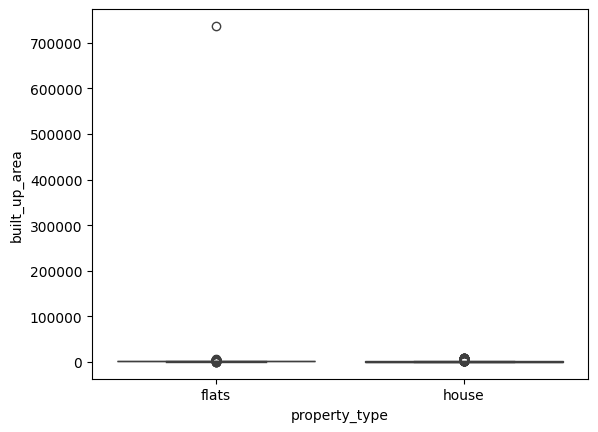

In [79]:
sns.boxplot(x=df['property_type'],y=df['built_up_area'])

In [80]:
#removing the outlier
df=df[df['built_up_area']!=737147]

<Axes: xlabel='property_type', ylabel='built_up_area'>

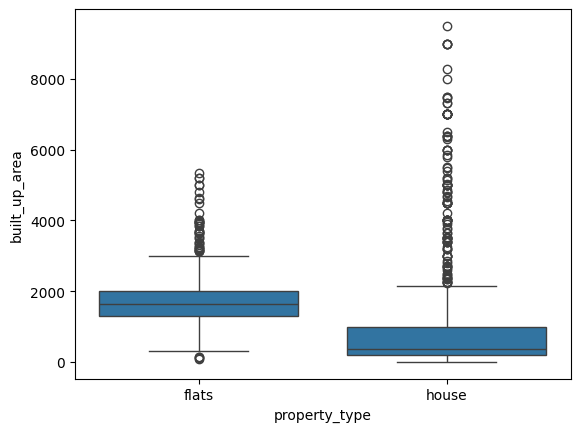

In [81]:
sns.boxplot(x=df['property_type'],y=df['built_up_area'])

property_type vs price_per_sqft

<Axes: xlabel='property_type', ylabel='price_per_sqft'>

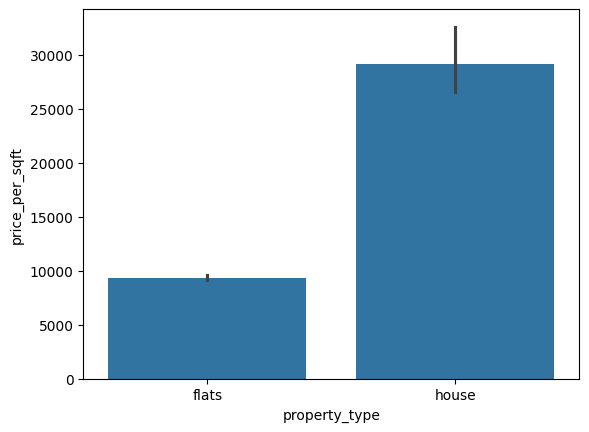

In [82]:
sns.barplot(x=df['property_type'], y=df['price_per_sqft'])

<Axes: xlabel='property_type', ylabel='price_per_sqft'>

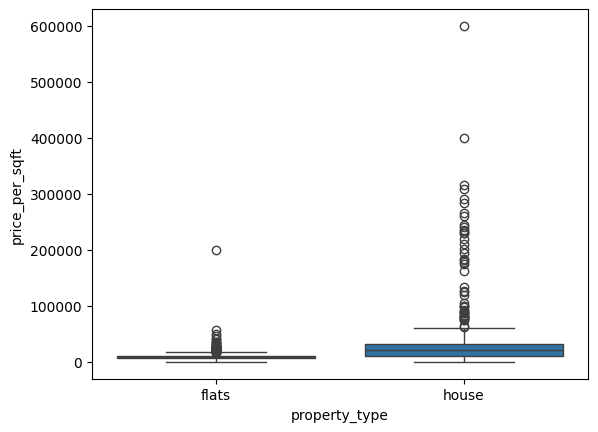

In [83]:
sns.boxplot(x=df['property_type'], y=df['price_per_sqft'])

<Axes: xlabel='bedRoom', ylabel='property_type'>

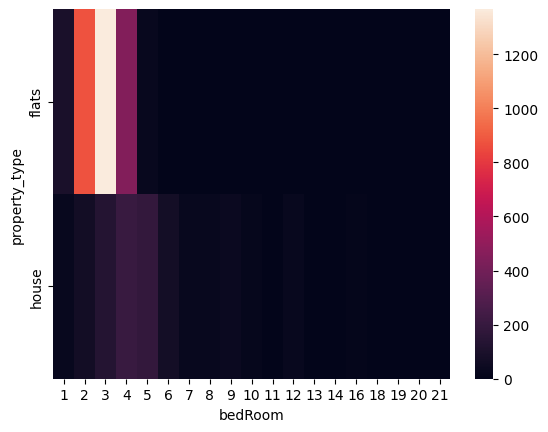

In [84]:
sns.heatmap(pd.crosstab(df['property_type'],df['bedRoom']))

<Axes: xlabel='property_type', ylabel='floorNum'>

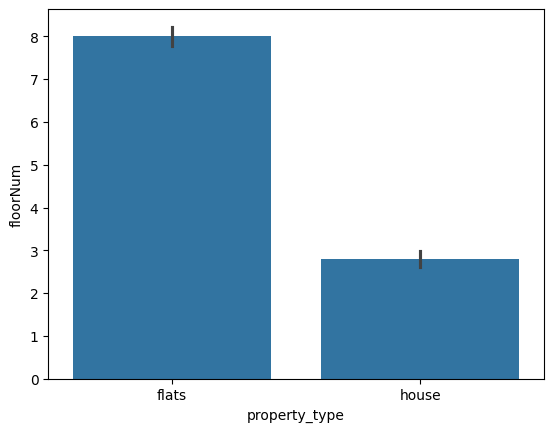

In [85]:
sns.barplot(x=df['property_type'],y=df['floorNum'])

<Axes: xlabel='property_type', ylabel='floorNum'>

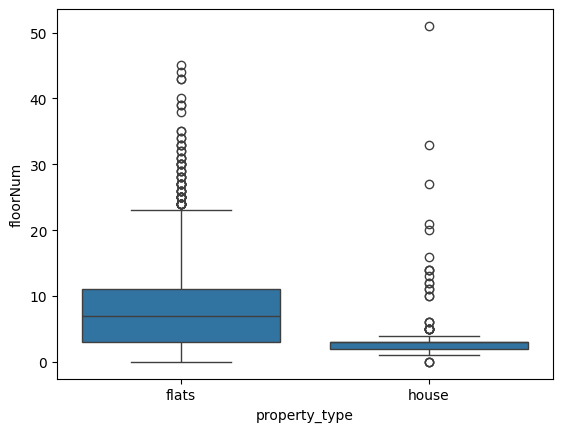

In [86]:
sns.boxplot(x=df['property_type'],y=df['floorNum'])

In [87]:
#houses having very high floor numbers mean these are houses in apartment

<Axes: xlabel='agePossession', ylabel='property_type'>

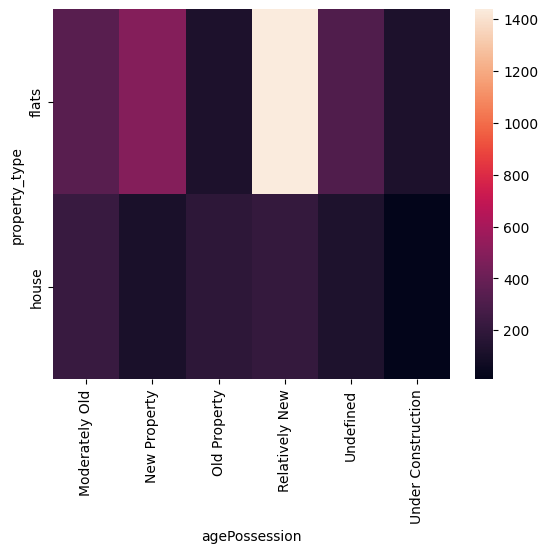

In [88]:
sns.heatmap(pd.crosstab(df['property_type'],df['agePossession']))

<Axes: xlabel='agePossession', ylabel='property_type'>

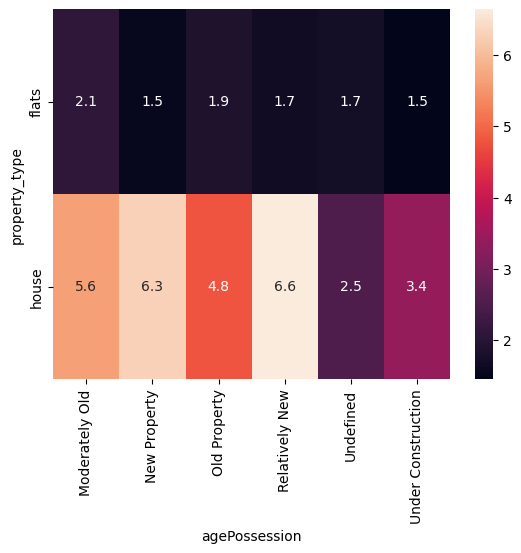

In [89]:
sns.heatmap(pd.pivot_table(df,index='property_type',columns='agePossession',values='price',aggfunc='mean'),annot=True)

<Axes: xlabel='bedRoom', ylabel='property_type'>

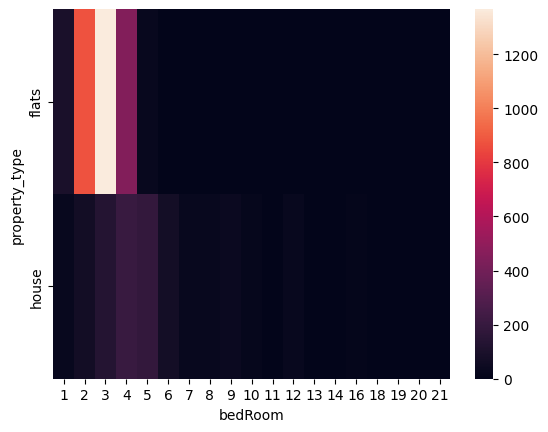

In [90]:
sns.heatmap(pd.crosstab(df['property_type'],df['bedRoom']))

<Axes: xlabel='bedRoom', ylabel='property_type'>

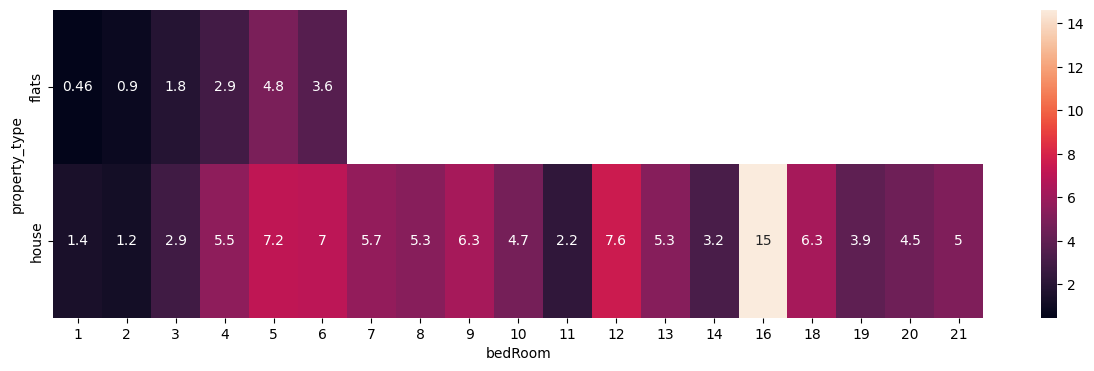

In [91]:
plt.figure(figsize=(15,4))
sns.heatmap(pd.pivot_table(df,index='property_type',columns='bedRoom',values='price',aggfunc='mean'),annot=True)

<Axes: xlabel='furnishing_type', ylabel='property_type'>

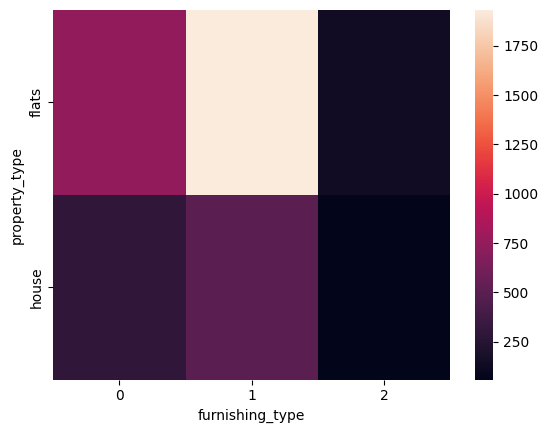

In [92]:
sns.heatmap(pd.crosstab(df['property_type'],df['furnishing_type']))

<Axes: xlabel='furnishing_type', ylabel='property_type'>

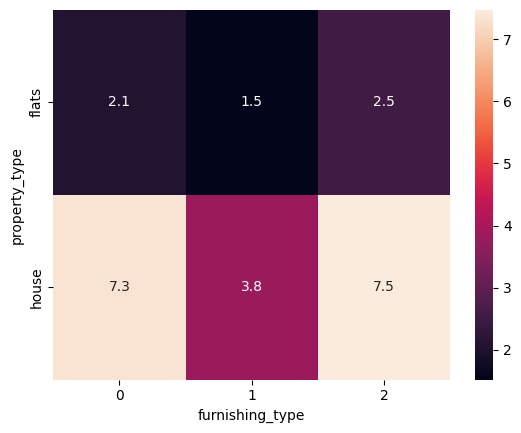

In [93]:
sns.heatmap(pd.pivot_table(df,index='property_type',columns='furnishing_type',values='price',aggfunc='mean'),annot=True)

<Axes: xlabel='property_type', ylabel='luxury_score'>

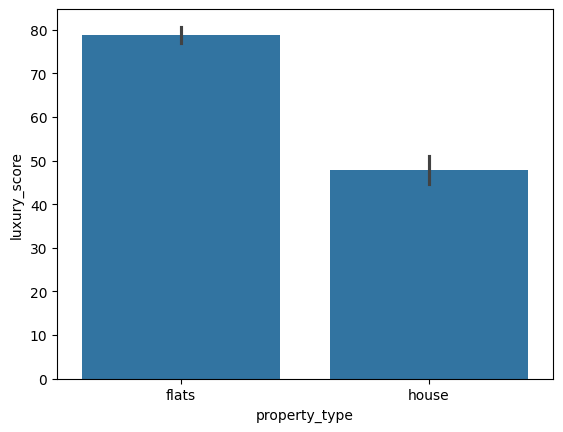

In [94]:
sns.barplot(x=df['property_type'],y=df['luxury_score'])

<Axes: xlabel='property_type', ylabel='luxury_score'>

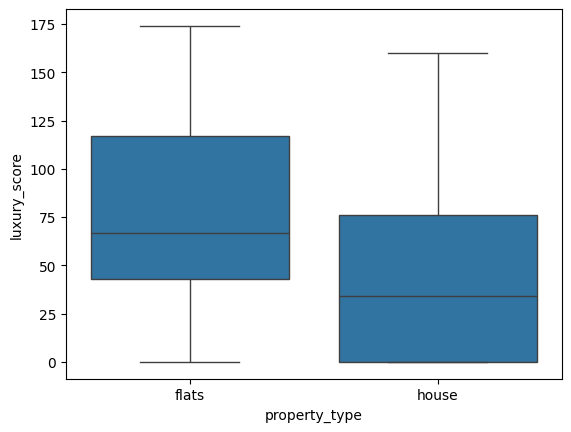

In [95]:
sns.boxplot(x=df['property_type'],y=df['luxury_score'])

<Axes: xlabel='sector', ylabel='property_type'>

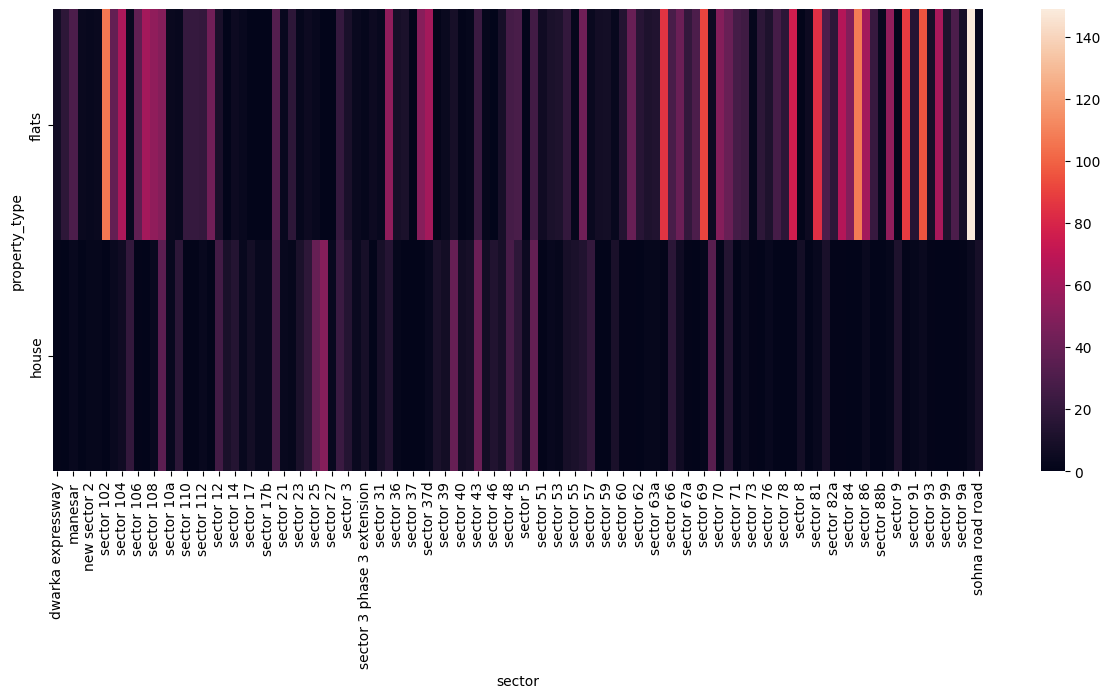

In [96]:
#sector analysis
plt.figure(figsize=(15,6))
sns.heatmap(pd.crosstab(df['property_type'],df['sector'].sort_index()))

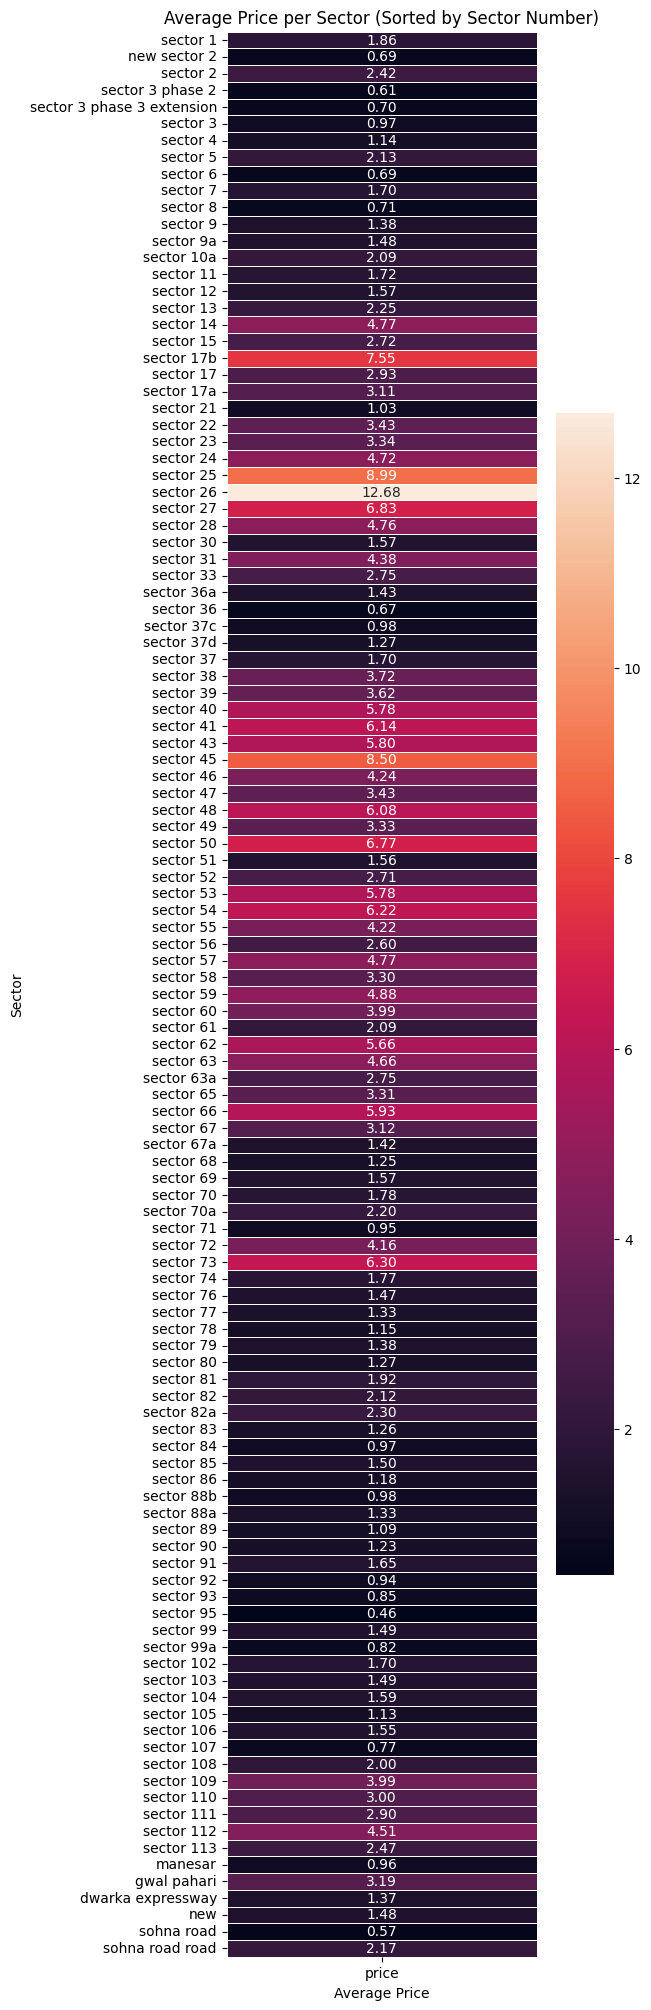

In [106]:
# sector analysis
import re
# Group by 'sector' and calculate the average price
avg_price_per_sector = df.groupby('sector')['price'].mean().reset_index()

# Function to extract sector numbers
def extract_sector_number(sector_name):
    match = re.search(r'\d+', sector_name)
    if match:
        return int(match.group())
    else:
        return float('inf')  # Return a large number for non-numbered sectors

avg_price_per_sector['sector_number'] = avg_price_per_sector['sector'].apply(extract_sector_number)

# Sort by sector number
avg_price_per_sector_sorted_by_sector = avg_price_per_sector.sort_values(by='sector_number')

# Plot the heatmap
plt.figure(figsize=(5, 25))
sns.heatmap(avg_price_per_sector_sorted_by_sector.set_index('sector')[['price']], annot=True, fmt=".2f", linewidths=.5)
plt.title('Average Price per Sector (Sorted by Sector Number)')
plt.xlabel('Average Price')
plt.ylabel('Sector')
plt.show()

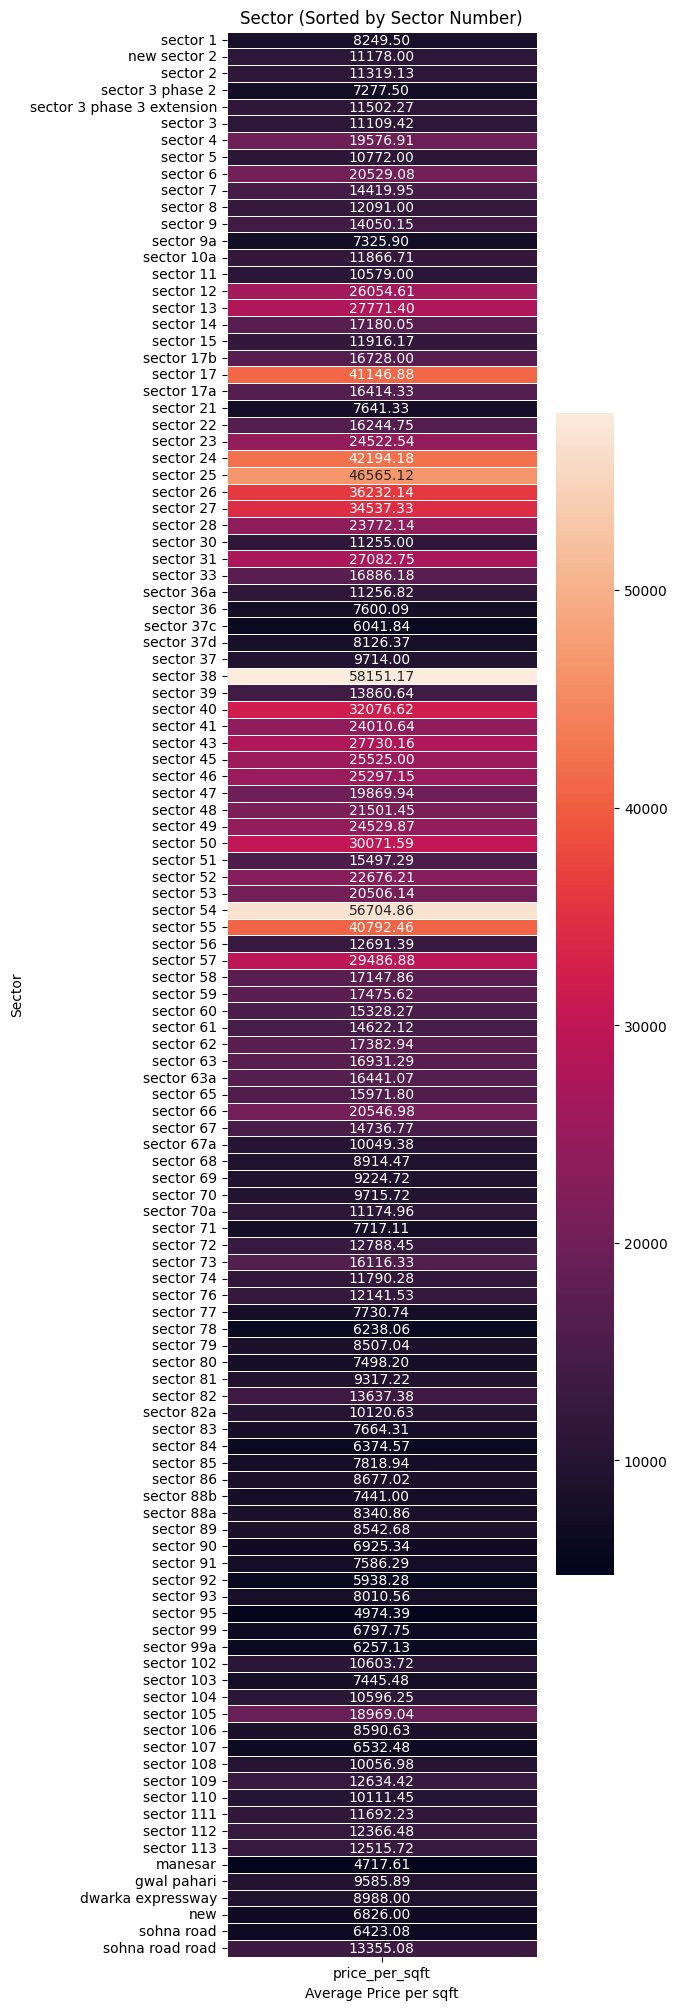

In [107]:
avg_price_per_sqft_sector = df.groupby('sector')['price_per_sqft'].mean().reset_index()

avg_price_per_sqft_sector['sector_number'] = avg_price_per_sqft_sector['sector'].apply(extract_sector_number)

# Sort by sector number
avg_price_per_sqft_sector_sorted_by_sector = avg_price_per_sqft_sector.sort_values(by='sector_number')

# Plot the heatmap
plt.figure(figsize=(5, 25))
sns.heatmap(avg_price_per_sqft_sector_sorted_by_sector.set_index('sector')[['price_per_sqft']], annot=True, fmt=".2f", linewidths=.5)
plt.title('Sector (Sorted by Sector Number)')
plt.xlabel('Average Price per sqft')
plt.ylabel('Sector')
plt.show()

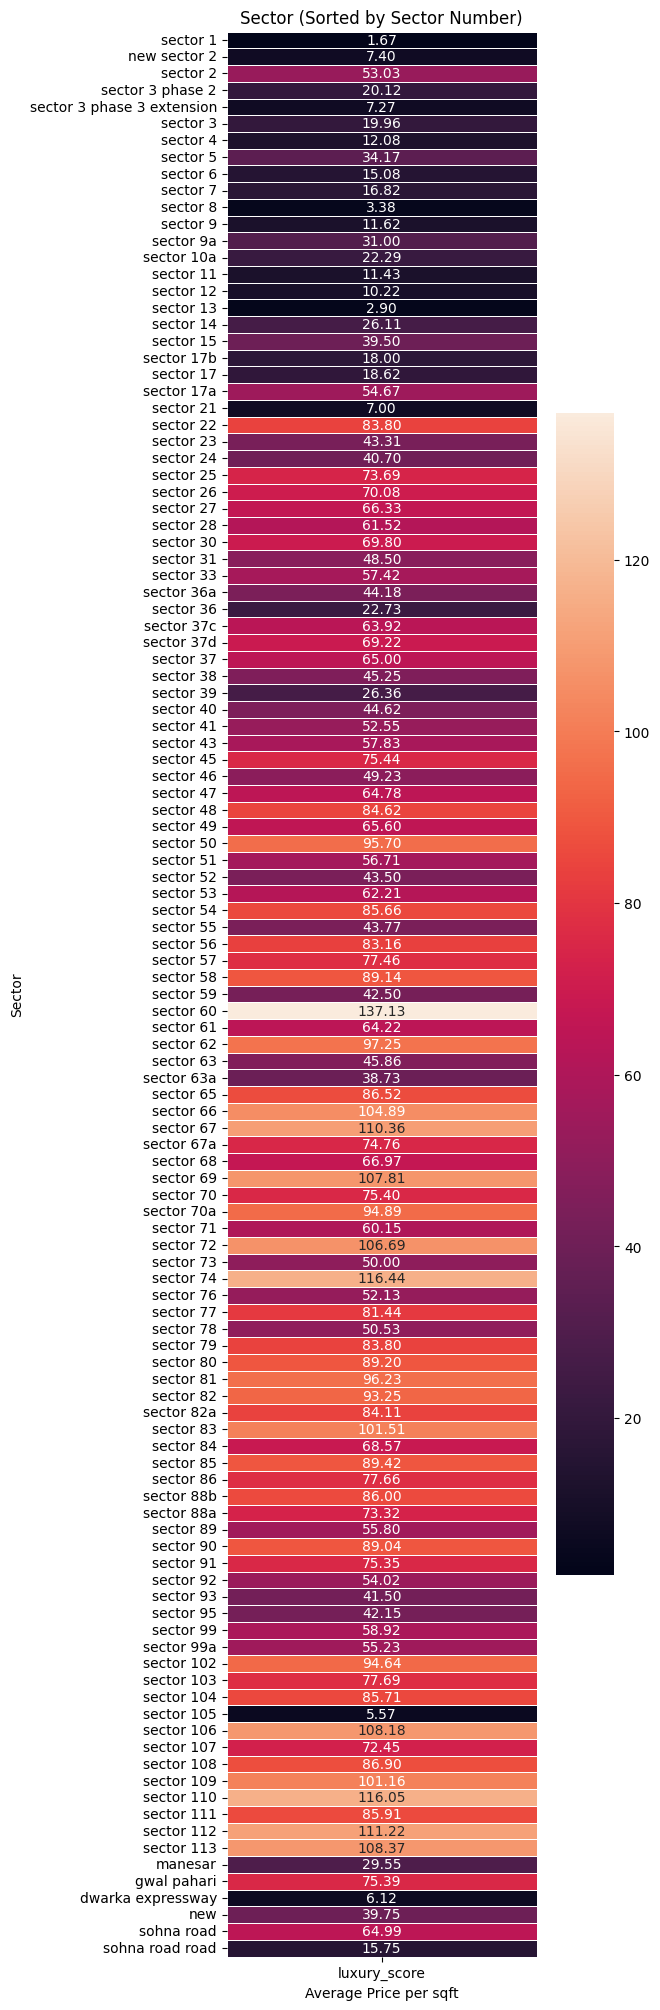

In [108]:
luxury_score = df.groupby('sector')['luxury_score'].mean().reset_index()

luxury_score['sector_number'] = luxury_score['sector'].apply(extract_sector_number)

# Sort by sector number
luxury_score_sector = luxury_score.sort_values(by='sector_number')

# Plot the heatmap
plt.figure(figsize=(5, 25))
sns.heatmap(luxury_score_sector.set_index('sector')[['luxury_score']], annot=True, fmt=".2f", linewidths=.5)
plt.title('Sector (Sorted by Sector Number)')
plt.xlabel('Average Price per sqft')
plt.ylabel('Sector')
plt.show()

price


<Axes: xlabel='area', ylabel='price'>

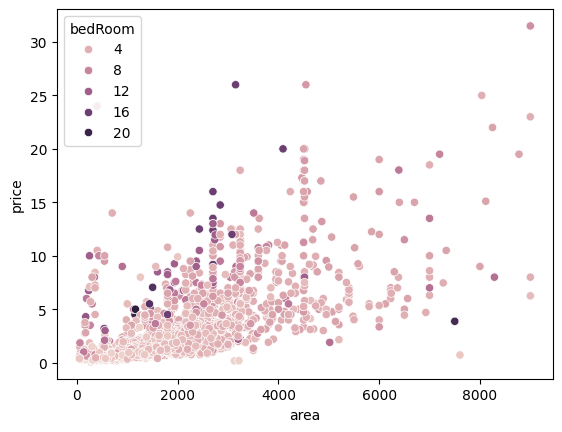

In [97]:
sns.scatterplot(
    data=df[df['area'] < 10000],
    x='area',
    y='price',
    hue='bedRoom'
)

<Axes: xlabel='area', ylabel='price'>

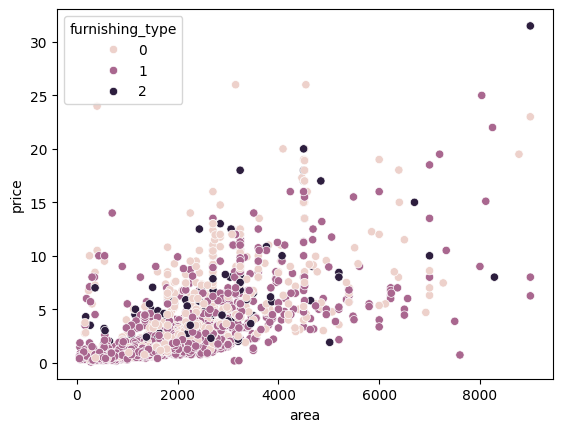

In [98]:
sns.scatterplot(
    data=df[df['area'] < 10000],
    x='area',
    y='price',
    hue='furnishing_type'
)

<Axes: xlabel='bedRoom', ylabel='price'>

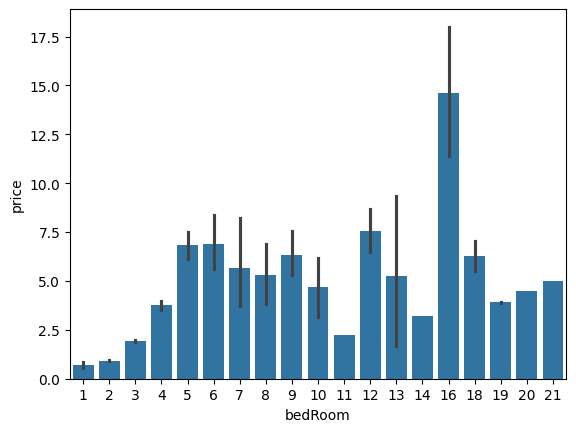

In [99]:
sns.barplot(x=df['bedRoom'],y=df['price'],estimator='mean')

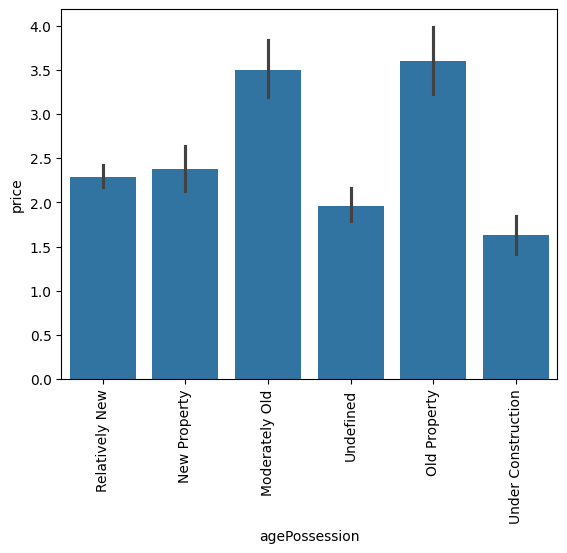

In [100]:
sns.barplot(x=df['agePossession'],y=df['price'],estimator='mean')
plt.xticks(rotation='vertical')
plt.show()

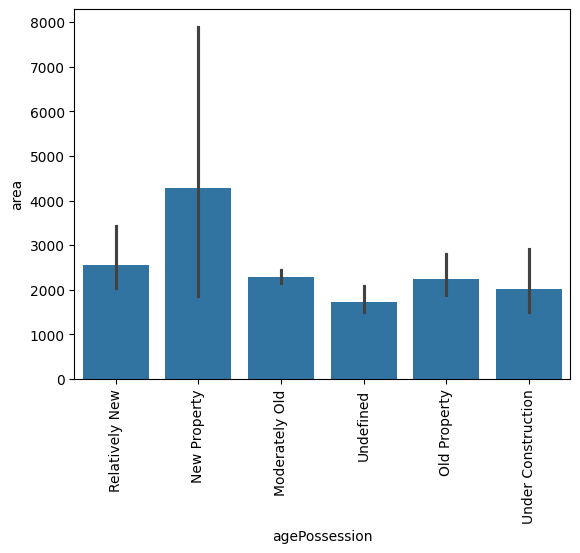

In [101]:
sns.barplot(x=df['agePossession'],y=df['area'],estimator='mean')
plt.xticks(rotation='vertical')
plt.show()

<Axes: xlabel='furnishing_type', ylabel='price'>

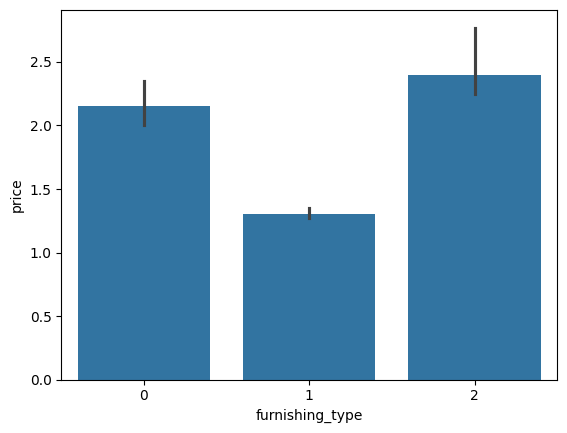

In [102]:
sns.barplot(x=df['furnishing_type'],y=df['price'],estimator=np.median)

<Axes: xlabel='luxury_score', ylabel='price'>

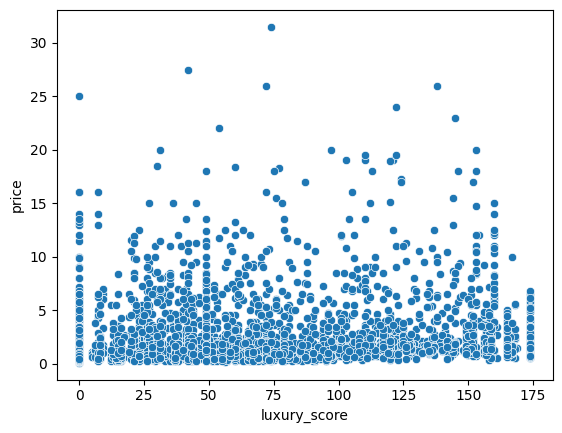

In [103]:
sns.scatterplot(x=df['luxury_score'],y=df['price'])

<Axes: >

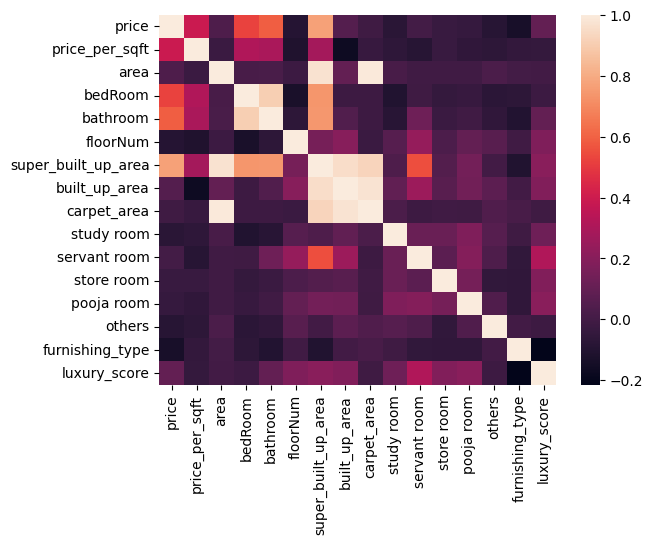

In [115]:
sns.heatmap(df.select_dtypes(include='number').corr())

In [116]:
df.select_dtypes(include='number').corr()['price'].sort_values(ascending=False)

price                  1.000000
super_built_up_area    0.769412
bathroom               0.589826
bedRoom                0.522925
price_per_sqft         0.391251
luxury_score           0.094775
built_up_area          0.052254
area                   0.034720
servant room           0.000603
carpet_area           -0.011344
store room            -0.032576
pooja room            -0.041501
study room            -0.077662
others                -0.086192
floorNum              -0.094290
furnishing_type       -0.133418
Name: price, dtype: float64

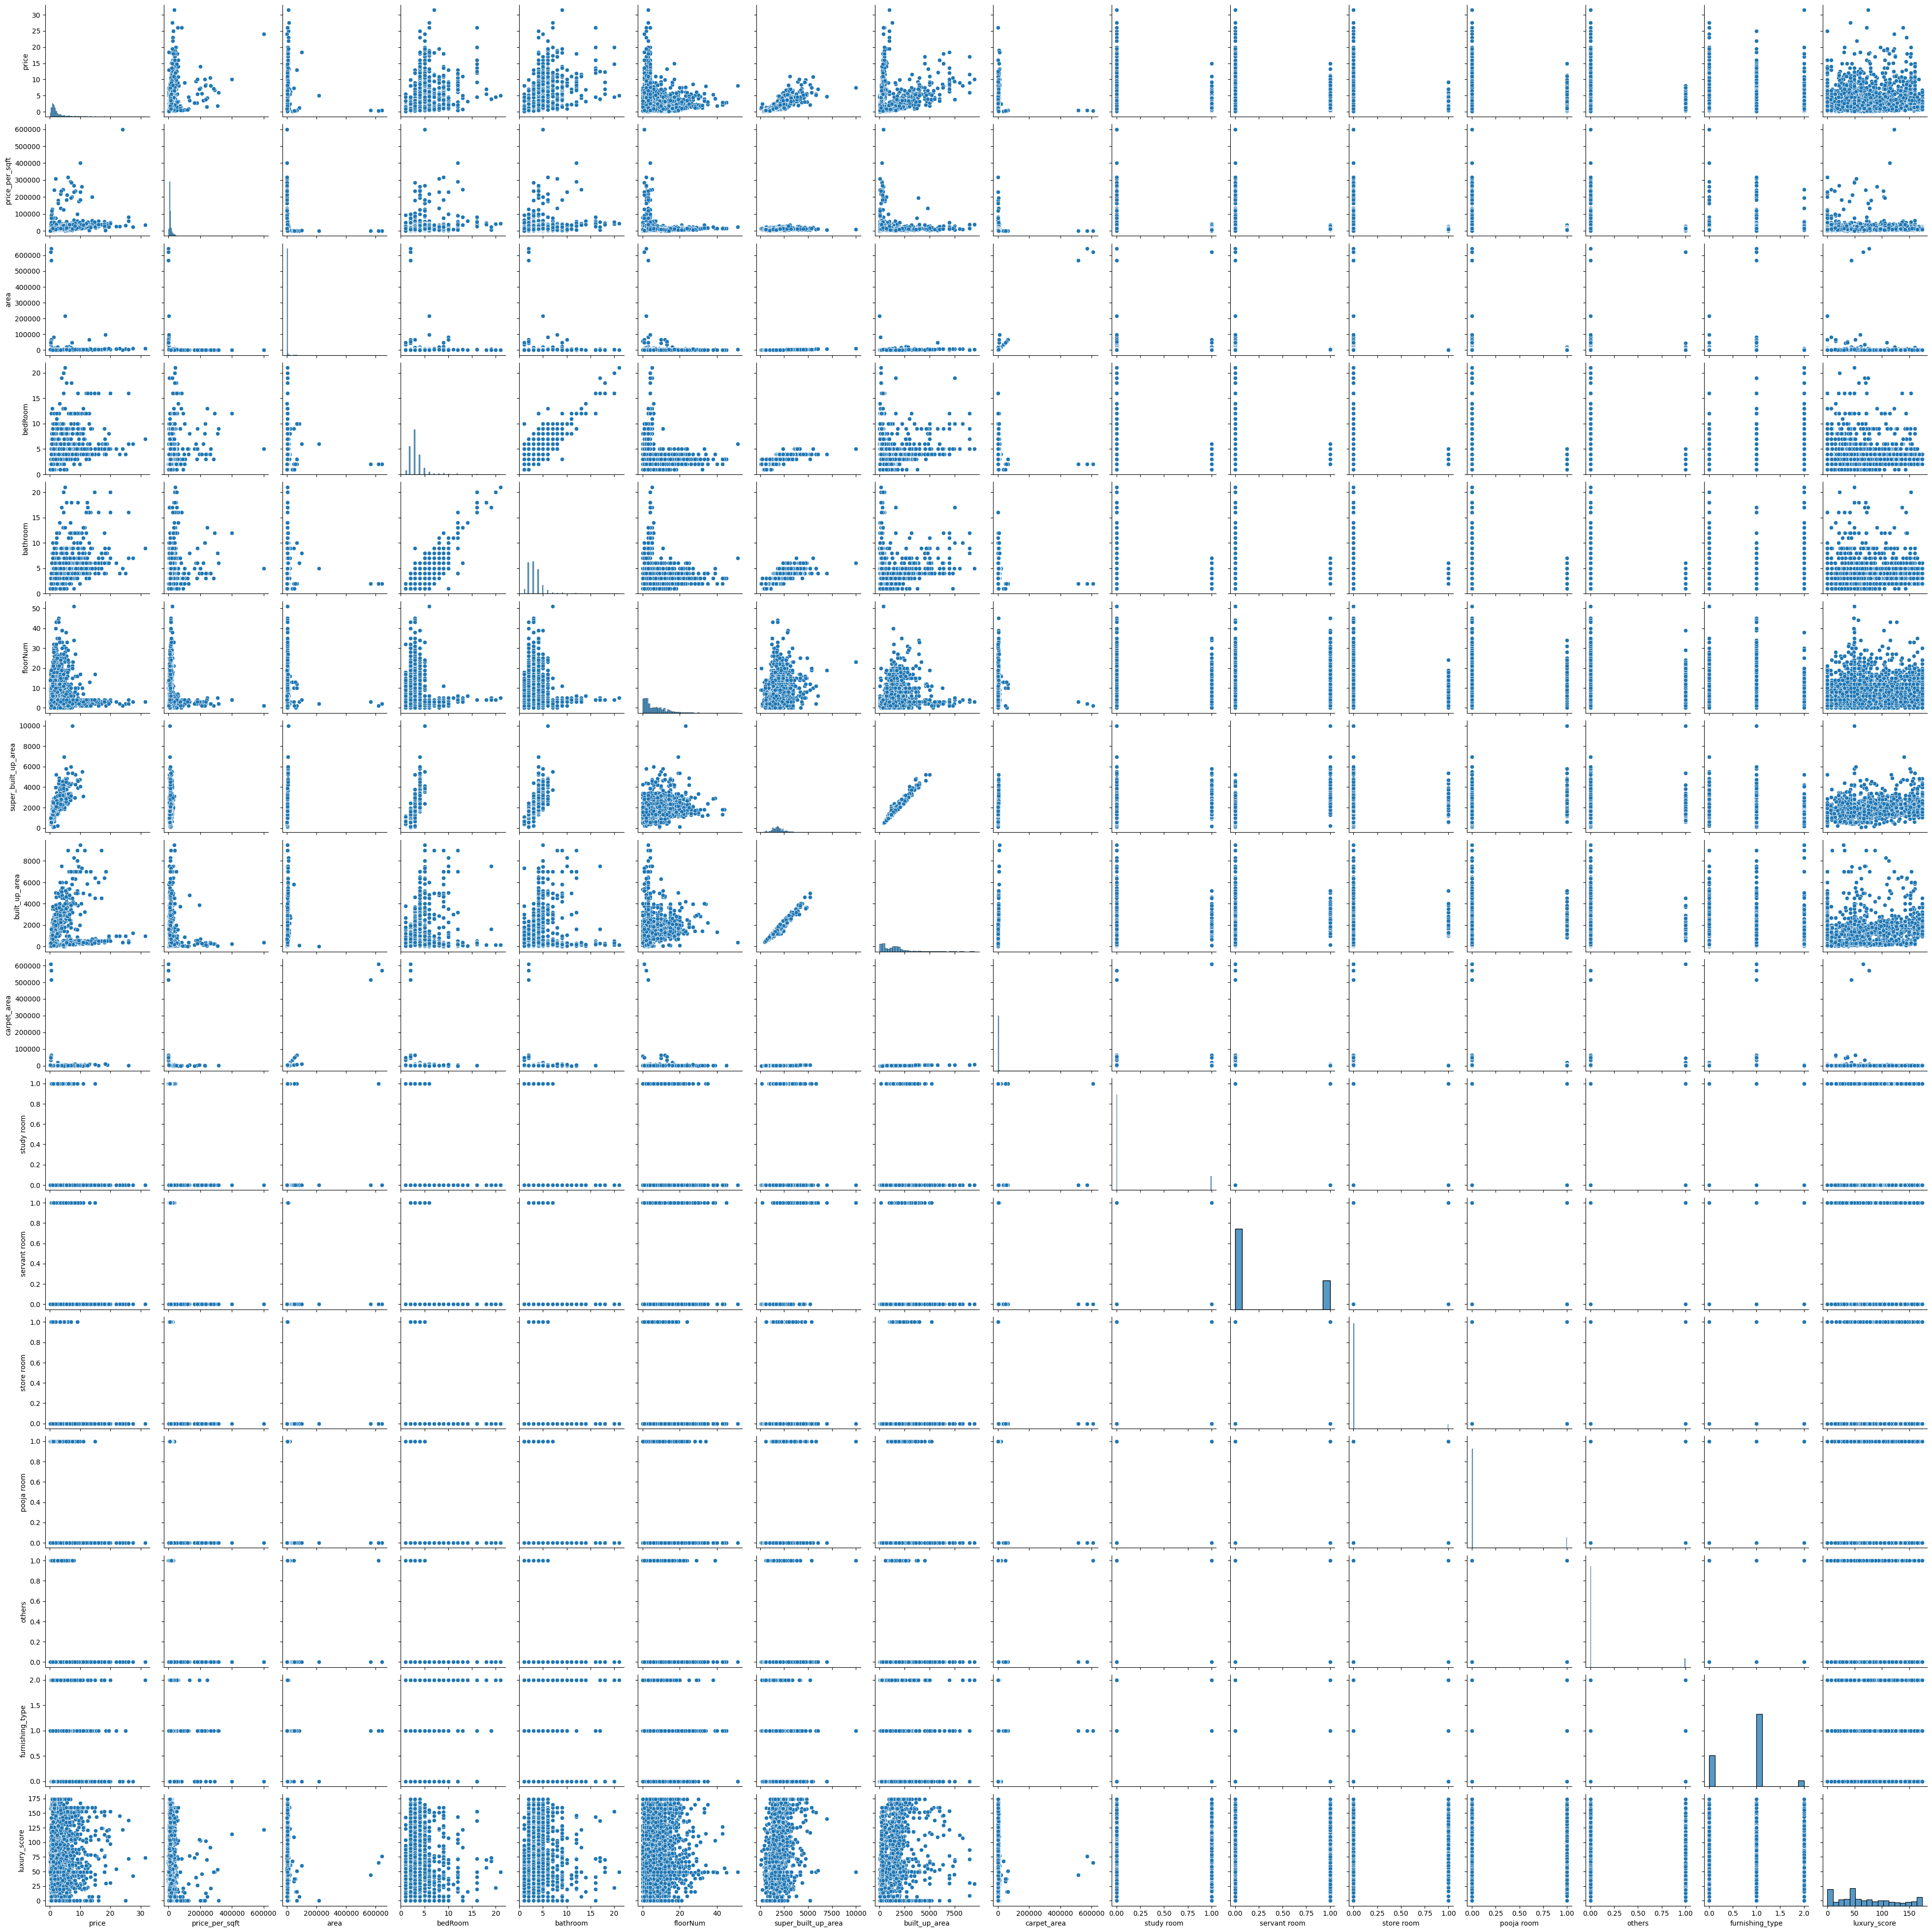

In [111]:

sns.pairplot(df)